# Insurance Fraud Detection

 Import Libraries and Reading the Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, recall_score
from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier, plot_tree

from google.colab import drive
drive.mount("/content/drive")

df = pd.read_csv("/content/drive/MyDrive/car_insurance_fraud.csv")

Mounted at /content/drive


In [2]:
df.shape
df.head()

,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,...,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,POL100000,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,...,MI,Charlesville,6,1,4,0,Yes,8161.36,11677.60,Y
1,POL100001,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,...,OH,Joshuaberg,0,3,4,5,No,18561.79,18027.81,N
2,POL100002,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,...,MI,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59,N
3,POL100003,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,...,NC,Josephchester,22,3,3,5,No,13188.92,14204.34,N
4,POL100004,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,...,NY,Caitlinfort,18,4,2,4,No,21864.69,24038.84,N


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   policy_id                    30000 non-null  object 
 1   policy_state                 30000 non-null  object 
 2   policy_deductible            30000 non-null  int64  
 3   policy_annual_premium        30000 non-null  float64
 4   insured_age                  30000 non-null  int64  
 5   insured_sex                  30000 non-null  object 
 6   insured_education_level      30000 non-null  object 
 7   insured_occupation           30000 non-null  object 
 8   insured_hobbies              30000 non-null  object 
 9   incident_date                30000 non-null  object 
 10  incident_type                30000 non-null  object 
 11  collision_type               30000 non-null  object 
 12  incident_severity            30000 non-null  object 
 13  authorities_cont

In [4]:
#numerical variable
print(df.describe().T)

                               count          mean          std     min  \
policy_deductible            30000.0    562.783333   250.413012  200.00   
policy_annual_premium        30000.0   1051.255214   260.357163  600.02   
insured_age                  30000.0     46.500133    16.707778   18.00   
incident_hour_of_the_day     30000.0     11.505000     6.896155    0.00   
number_of_vehicles_involved  30000.0      2.508933     1.116555    1.00   
bodily_injuries              30000.0      1.997600     1.411829    0.00   
witnesses                    30000.0      2.504667     1.707691    0.00   
claim_amount                 30000.0  10823.078981  6629.690781  266.74   
total_claim_amount           30000.0  12757.736600  7028.920069  502.18   

                                   25%        50%         75%       max  
policy_deductible             300.0000    600.000    800.0000   1000.00  
policy_annual_premium         826.3200   1051.155   1277.9025   1499.98  
insured_age                

In [5]:
#categorical variables
print(df.describe(include='object').T)

                         count unique            top   freq
policy_id                30000  30000      POL129983      1
policy_state             30000     10             GA   3133
insured_sex              30000      3          OTHER  10088
insured_education_level  30000      4    High School   7554
insured_occupation       30000      8        Teacher   3799
insured_hobbies          30000      7      paintball   4345
incident_date            30000    731     2024-07-31     64
incident_type            30000      4  Vehicle Theft   7581
collision_type           30000      4           Rear   7566
incident_severity        30000      3     Total Loss  10108
authorities_contacted    22436      3           Fire   7569
incident_state           30000     10             TX   3077
incident_city            30000  17931   Lake Michael     33
police_report_available  30000      2             No  15099
fraud_reported           30000      2              N  26560


In [6]:
#missing values

df = df.replace("?", np.nan)

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("Missing % (top 10):")
display(missing_pct.head(10))

Missing % (top 10):


,0
authorities_contacted,25.213333
collision_type,24.776667
policy_id,0.000000
policy_state,0.000000
insured_age,0.000000
insured_sex,0.000000
policy_deductible,0.000000
policy_annual_premium,0.000000
insured_occupation,0.000000
insured_education_level,0.000000


In [7]:
cols_to_drop = [
    "policy_id",
    "policy_state",
    "claim_amount",
    "incident_date",
    "incident_city",
    "insured_hobbies",
    "incident_hour_of_the_day"
]

df_clean = df.drop(columns=cols_to_drop)
print("New shape after drop:", df_clean.shape)


New shape after drop: (30000, 17)


fraud_reported
N    26560
Y     3440
Name: count, dtype: int64
fraud_reported
N    0.885333
Y    0.114667
Name: proportion, dtype: float64


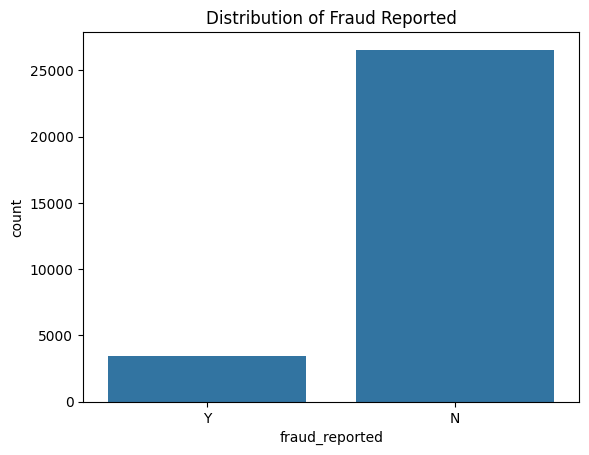

In [8]:
# Target Variable and Distribution
target_counts = df_clean['fraud_reported'].value_counts()
target_pct = df_clean['fraud_reported'].value_counts(normalize=True)

print(target_counts)
print(target_pct)

sns.countplot(x='fraud_reported', data=df_clean)
plt.title('Distribution of Fraud Reported')
plt.show()

In [9]:
# Fill missing values

num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns

# numeric
for col in num_cols:
    if df_clean[col].isnull().any():
        med_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(med_val)

# categorical
for col in cat_cols:
    if df_clean[col].isnull().any():
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)

In [10]:
# Group Education Levels
def group_education(level):
    if level in ['High School', 'Associate']:
        return 'Basic'
    elif level in ['College', 'Masters']:
        return 'Academic'
    else:
        return 'Advanced'

if 'insured_education_level' in df_clean.columns:
    df_clean['education_group'] = df_clean['insured_education_level'].apply(group_education)
    df_clean.drop('insured_education_level', axis=1, inplace=True)
    print("\nCreated 'education_group' and dropped 'insured_education_level'")
else:
    print("\n'insured_education_level' column not found, likely already processed.")


Created 'education_group' and dropped 'insured_education_level'


In [11]:
# Age distribution
bins = [0, 30, 50, 100]
labels = ['Young', 'Mid', 'Senior']
df_clean['age_group'] = pd.cut(df_clean['insured_age'], bins=bins, labels=labels)

df_clean.drop('insured_age', axis=1, inplace=True)
print("Created 'age_group' and dropped 'insured_age'")

Created 'age_group' and dropped 'insured_age'


Numeric Variables to Check: ['policy_deductible', 'policy_annual_premium', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount']

Variable: policy_deductible | Skewness: 0.23


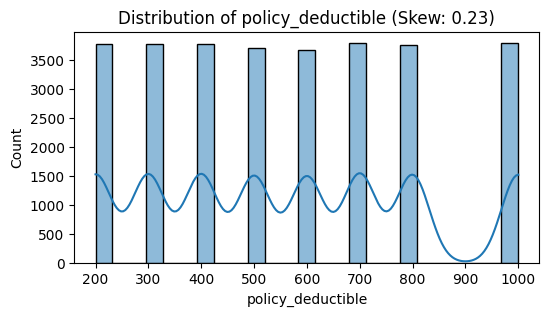


Variable: policy_annual_premium | Skewness: -0.00


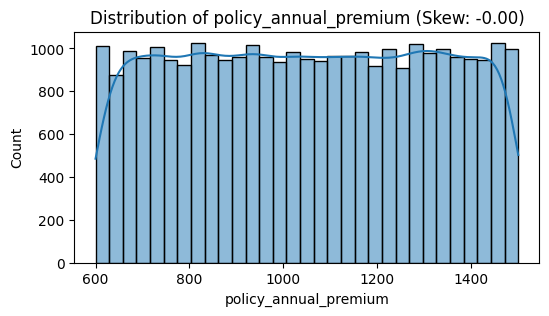


Variable: number_of_vehicles_involved | Skewness: -0.01


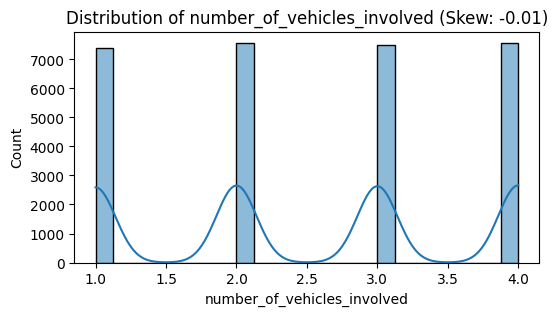


Variable: bodily_injuries | Skewness: 0.00


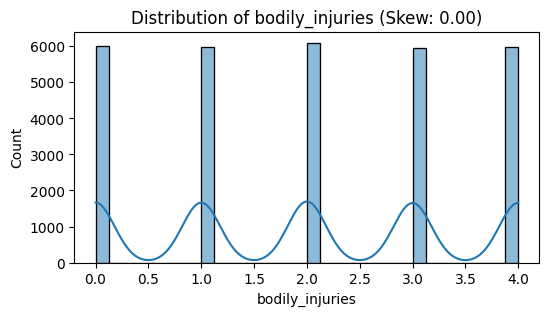


Variable: witnesses | Skewness: 0.00


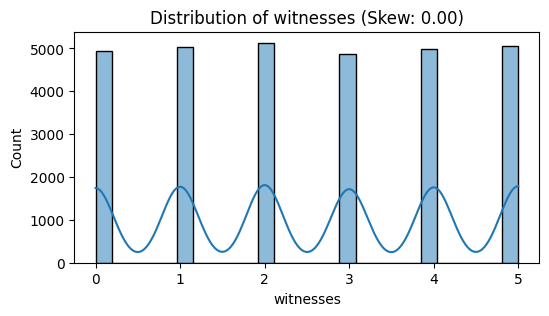


Variable: total_claim_amount | Skewness: 0.00


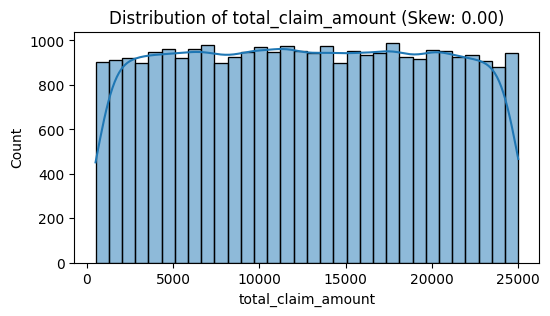

In [12]:
# Checking the skewness of the variables.
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns #Making sure all Numeric Cols are chosen.
numeric_cols = [c for c in numeric_cols if c not in ['fraud_reported']]

print(f"Numeric Variables to Check: {numeric_cols}")

for col in numeric_cols:
    skew_val = df_clean[col].skew()
    print(f"\nVariable: {col} | Skewness: {skew_val:.2f}")

    plt.figure(figsize=(6, 3))
    sns.histplot(df_clean[col], kde=True)
    plt.title(f'Distribution of {col} (Skew: {skew_val:.2f})')
    plt.show()

In [20]:
y = (df_clean['fraud_reported'] == 'Y').astype(int)
X = df_clean.drop('fraud_reported', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y)

print(f"Original Training Counts:\n{y_train.value_counts()}")
print(f"Original Test Counts:\n{y_test.value_counts()}")

Original Training Counts:
fraud_reported
0    13280
1     1720
Name: count, dtype: int64
Original Test Counts:
fraud_reported
0    13280
1     1720
Name: count, dtype: int64


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def eval_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    }

def labeled_cm(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return pd.DataFrame(cm,
                        index=["Actual: No Fraud", "Actual: Fraud"],
                        columns=["Pred: No Fraud", "Pred: Fraud"])

In [14]:
#Dummy Coding

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (21000, 38)
X_test shape: (9000, 38)


In [15]:
# Using Undersampling
train_data = pd.concat([X_train, y_train.rename("fraud_reported")], axis=1)

classMajority = train_data[train_data['fraud_reported'] == 0] # No Fraud
classMinority = train_data[train_data['fraud_reported'] == 1] # Fraud

majority_downsampled = resample(
    classMajority,
    replace=False,
    n_samples=len(classMinority),
    random_state=42)

train_balanced = pd.concat([majority_downsampled, classMinority])

y_train_bal = train_balanced['fraud_reported']
X_train_bal = train_balanced.drop('fraud_reported', axis=1)

print(y_train_bal.value_counts())


fraud_reported
0    2408
1    2408
Name: count, dtype: int64


                         Feature  Coefficient  Odds_Ratio
22    authorities_contacted_Fire     0.697466    2.008656
21  incident_severity_Total Loss     0.466952    1.595125
12      insured_occupation_Sales     0.129064    1.137763
19           collision_type_Side     0.099068    1.104141
28             incident_state_NC     0.076765    1.079788


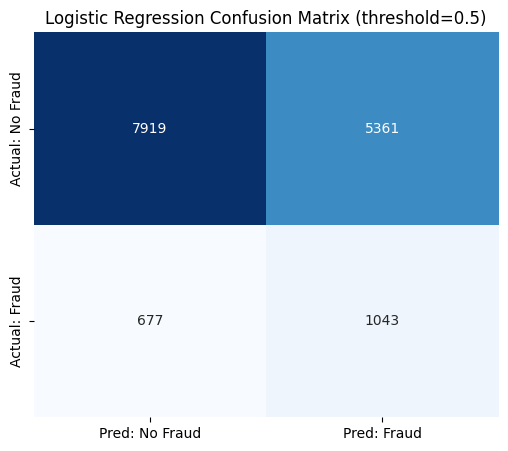

In [24]:
# Logistic Regression Model

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

if len(cat_cols) > 0:
    print(f"One-hot encoding categorical columns: {list(cat_cols)}")
    X_train_enc = pd.get_dummies(X_train_enc, columns=cat_cols, drop_first=True)
    X_test_enc = pd.get_dummies(X_test_enc, columns=cat_cols, drop_first=True)
    X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

log_reg = LogisticRegression(
    C=0.5,
    max_iter=10000,
    random_state=42,
    class_weight='balanced'
)

log_reg.fit(X_train_enc, y_train)

coeffs = log_reg.coef_[0]
coef_df = pd.DataFrame({
    "Feature": X_train_enc.columns,
    "Coefficient": coeffs,
    "Odds_Ratio": np.exp(coeffs)
})

print(coef_df.sort_values(by="Odds_Ratio", ascending=False).head(5))

threshold = 0.50
y_prob_log = log_reg.predict_proba(X_test_enc)[:, 1]
y_pred_log = (y_prob_log >= threshold).astype(int)

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

log_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "Precision": precision_score(y_test, y_pred_log, zero_division=0),
    "Recall": recall_score(y_test, y_pred_log, zero_division=0),
    "F1": f1_score(y_test, y_pred_log, zero_division=0)
}
pd.DataFrame([log_metrics])

# Labeled confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_log, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=["Pred: No Fraud", "Pred: Fraud"],
    yticklabels=["Actual: No Fraud", "Actual: Fraud"]
)
plt.title(f"Logistic Regression Confusion Matrix (threshold={threshold})")
plt.ylabel("")
plt.xlabel("")
plt.show()

In [17]:
# Baseline Accuracy
baseline_acc = y_test.value_counts(normalize=True).max()

# Model Accuracy
model_acc = accuracy_score(y_test, y_pred_log)

#Recall scores
recall_val = recall_score(y_test, y_pred_log)
print(f"The Recall for the model is: {recall_val:.2%}")

print(f"Baseline Accuracy: {baseline_acc:.2%}")
print(f"Model Accuracy: {model_acc:.2%}")


The Recall for the model is: 43.31%
Baseline Accuracy: 88.53%
Model Accuracy: 69.23%


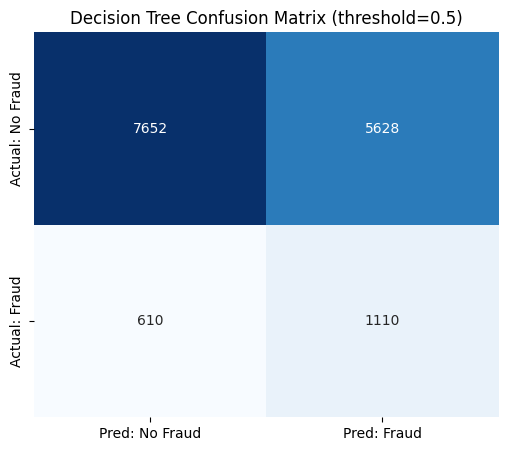

In [25]:
# Decision Tree Model

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

threshold = 0.50

dtree = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,      # helps prevent tiny leaf splits
    random_state=42,
    class_weight="balanced"   # helps with class imbalance
)

dtree.fit(X_train_enc, y_train)

# Predictions
y_prob_tree = dtree.predict_proba(X_test_enc)[:, 1]
y_pred_tree = (y_prob_tree >= threshold).astype(int)

# Metrics
tree_metrics = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred_tree),
    "Precision": precision_score(y_test, y_pred_tree, zero_division=0),
    "Recall": recall_score(y_test, y_pred_tree, zero_division=0),
    "F1": f1_score(y_test, y_pred_tree, zero_division=0)
}

pd.DataFrame([tree_metrics])

# Labeled confusion matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_tree, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["Pred: No Fraud", "Pred: Fraud"],
    yticklabels=["Actual: No Fraud", "Actual: Fraud"]
)
plt.title(f"Decision Tree Confusion Matrix (threshold={threshold})")
plt.ylabel("")
plt.xlabel("")
plt.show()


In [29]:
#side by side comparison
q1_summary = pd.DataFrame([log_metrics, tree_metrics])
q1_summary

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.597467,0.162867,0.606395,0.256770
1,Decision Tree,0.584133,0.164737,0.645349,0.262473


In [30]:
# Random forest run 1
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Random Forest - First Run
rf1 = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf1.fit(X_train_enc, y_train)

# Predictions
y_pred_rf1 = rf1.predict(X_test_enc)

# Metrics
rf1_metrics = {
    "Model": "Random Forest (Run 1)",
    "Accuracy": accuracy_score(y_test, y_pred_rf1),
    "Precision": precision_score(y_test, y_pred_rf1, zero_division=0),
    "Recall": recall_score(y_test, y_pred_rf1, zero_division=0),
    "F1": f1_score(y_test, y_pred_rf1, zero_division=0)
}

pd.DataFrame([rf1_metrics])

,Model,Accuracy,Precision,Recall,F1
0,Random Forest (Run 1),0.862,0.350937,0.239535,0.284727


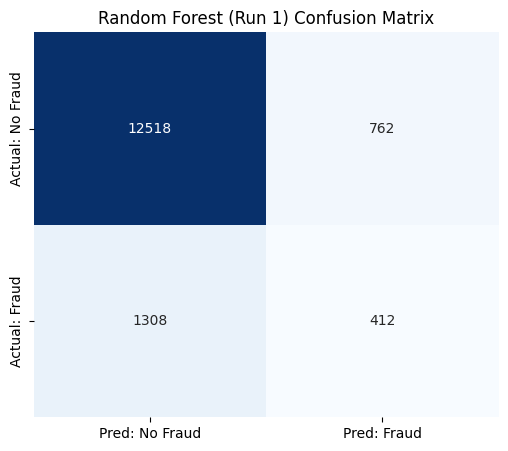

In [31]:
cm_rf1 = confusion_matrix(y_test, y_pred_rf1)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_rf1,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Pred: No Fraud", "Pred: Fraud"],
    yticklabels=["Actual: No Fraud", "Actual: Fraud"]
)
plt.title("Random Forest (Run 1) Confusion Matrix")
plt.xlabel("")
plt.ylabel("")
plt.show()

In [32]:
# Random Forest - Run 2

rf2 = RandomForestClassifier(
    n_estimators=700,
    max_depth=None,           =
    min_samples_leaf=2,
    min_samples_split=5,
    max_features=0.6,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf2.fit(X_train_enc, y_train)

# Predictions
y_pred_rf2 = rf2.predict(X_test_enc)

# Metrics
rf2_metrics = {
    "Model": "Random Forest (Run 2)",
    "Accuracy": accuracy_score(y_test, y_pred_rf2),
    "Precision": precision_score(y_test, y_pred_rf2, zero_division=0),
    "Recall": recall_score(y_test, y_pred_rf2, zero_division=0),
    "F1": f1_score(y_test, y_pred_rf2, zero_division=0)
}

pd.DataFrame([rf2_metrics])

,Model,Accuracy,Precision,Recall,F1
0,Random Forest (Run 2),0.8798,0.40048,0.097093,0.156294


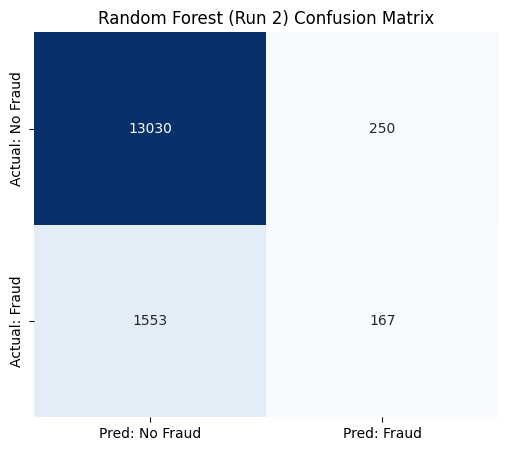

In [33]:
cm_rf2 = confusion_matrix(y_test, y_pred_rf2)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_rf2,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Pred: No Fraud", "Pred: Fraud"],
    yticklabels=["Actual: No Fraud", "Actual: Fraud"]
)
plt.title("Random Forest (Run 2) Confusion Matrix")
plt.xlabel("")
plt.ylabel("")
plt.show()

In [34]:
# Fine tune Random forest (grid search)

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rf_base = RandomForestClassifier(
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [10, None],
    "min_samples_leaf": [2, 5],
    "max_features": ["sqrt", 0.6]
}
# Total combos = 2*2*2*2 = 16

rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_enc, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV F1:", rf_grid.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 300}
Best CV F1: 0.26350392116670845


In [38]:
best_rf = rf_grid.best_estimator_

y_pred_best = best_rf.predict(X_test_enc)

best_metrics = {
    "Model": "Random Forest (Tuned)",
    "Accuracy": accuracy_score(y_test, y_pred_best),
    "Precision": precision_score(y_test, y_pred_best, zero_division=0),
    "Recall": recall_score(y_test, y_pred_best, zero_division=0),
    "F1": f1_score(y_test, y_pred_best, zero_division=0)
}

pd.DataFrame([best_metrics])

import pandas as pd

importances = pd.DataFrame({
    "Feature": X_train_enc.columns,
    "Importance": best_rf.feature_importances_
}).sort_values("Importance", ascending=False)

importances.head(10)

,Feature,Importance
4,witnesses,0.141357
5,total_claim_amount,0.110154
1,policy_annual_premium,0.108880
22,authorities_contacted_Fire,0.079054
21,incident_severity_Total Loss,0.060300
0,policy_deductible,0.053405
3,bodily_injuries,0.038845
2,number_of_vehicles_involved,0.034030
23,authorities_contacted_Police,0.027176
20,incident_severity_Minor Damage,0.022159


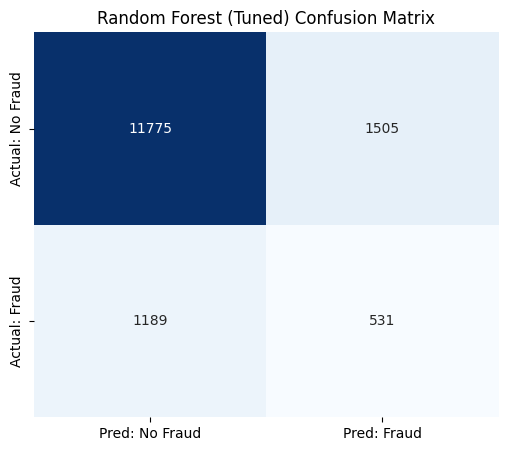

In [36]:
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_best, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["Pred: No Fraud", "Pred: Fraud"],
    yticklabels=["Actual: No Fraud", "Actual: Fraud"]
)
plt.title("Random Forest (Tuned) Confusion Matrix")
plt.xlabel("")
plt.ylabel("")
plt.show()

In [39]:
# SVM

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


svm_linear = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("svm", SVC(kernel="linear", C=1.0, gamma="scale", probability=True, random_state=42))
])

svm_linear.fit(X_train_enc, y_train)

y_pred_lin = svm_linear.predict(X_test_enc)

lin_metrics = {
    "Model": "SVM (Linear)",
    "Accuracy": accuracy_score(y_test, y_pred_lin),
    "Precision": precision_score(y_test, y_pred_lin, zero_division=0),
    "Recall": recall_score(y_test, y_pred_lin, zero_division=0),
    "F1": f1_score(y_test, y_pred_lin, zero_division=0)
}

pd.DataFrame([lin_metrics])

,Model,Accuracy,Precision,Recall,F1
0,SVM (Linear),0.885333,0.0,0.0,0.0


In [40]:
svm_rbf = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))
])

svm_rbf.fit(X_train_enc, y_train)

y_pred_rbf = svm_rbf.predict(X_test_enc)

rbf_metrics = {
    "Model": "SVM (RBF)",
    "Accuracy": accuracy_score(y_test, y_pred_rbf),
    "Precision": precision_score(y_test, y_pred_rbf, zero_division=0),
    "Recall": recall_score(y_test, y_pred_rbf, zero_division=0),
    "F1": f1_score(y_test, y_pred_rbf, zero_division=0)
}

pd.DataFrame([rbf_metrics])

,Model,Accuracy,Precision,Recall,F1
0,SVM (RBF),0.885333,0.0,0.0,0.0


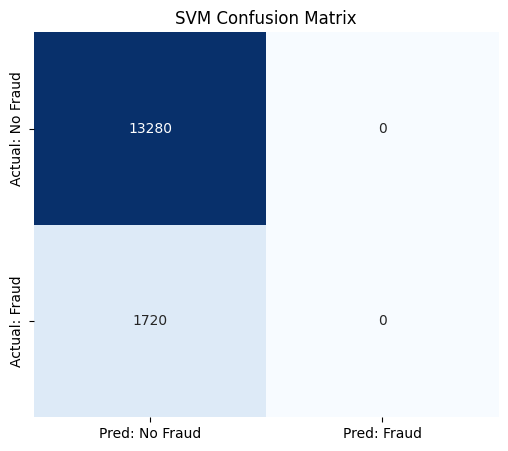

In [41]:
cm_svm = confusion_matrix(y_test, y_pred_rbf)  # or y_pred_lin depending on winner

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_svm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["Pred: No Fraud", "Pred: Fraud"],
    yticklabels=["Actual: No Fraud", "Actual: Fraud"]
)
plt.title("SVM Confusion Matrix")
plt.xlabel("")
plt.ylabel("")
plt.show()

In [43]:
# Fine-tuning SVM

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.utils import resample

train_df = pd.concat([X_train_enc, y_train], axis=1)

fraud = train_df[train_df[y_train.name] == 1]
nonfraud = train_df[train_df[y_train.name] == 0]

# sample sizes
fraud_s = resample(fraud, n_samples=min(1200, len(fraud)), random_state=42, replace=False)
nonfraud_s = resample(nonfraud, n_samples=min(4800, len(nonfraud)), random_state=42, replace=False)

train_small = pd.concat([fraud_s, nonfraud_s]).sample(frac=1, random_state=42)

X_train_small = train_small.drop(columns=[y_train.name])
y_train_small = train_small[y_train.name]

svm_pipeline = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("svm", SVC(class_weight="balanced", random_state=42))
])

param_grid = {
    "svm__kernel": ["linear", "rbf"],
    "svm__C": [0.5, 1, 2],
    "svm__gamma": ["scale", 0.1]
}


svm_grid = GridSearchCV(
    svm_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=2,          # faster
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_small, y_train_small)

print("Best Parameters:", svm_grid.best_params_)
print("Best CV F1:", svm_grid.best_score_)

Fitting 2 folds for each of 12 candidates, totalling 24 fits
Best Parameters: {'svm__C': 0.5, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best CV F1: 0.34427490399819294


In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

best_svm = svm_grid.best_estimator_

y_pred_best_svm = best_svm.predict(X_test_enc)

svm_metrics = {
    "Model": "SVM (Tuned)",
    "Accuracy": accuracy_score(y_test, y_pred_best_svm),
    "Precision": precision_score(y_test, y_pred_best_svm, zero_division=0),
    "Recall": recall_score(y_test, y_pred_best_svm, zero_division=0),
    "F1": f1_score(y_test, y_pred_best_svm, zero_division=0)
}

pd.DataFrame([svm_metrics])

,Model,Accuracy,Precision,Recall,F1
0,SVM (Tuned),0.5796,0.1614,0.635465,0.257419


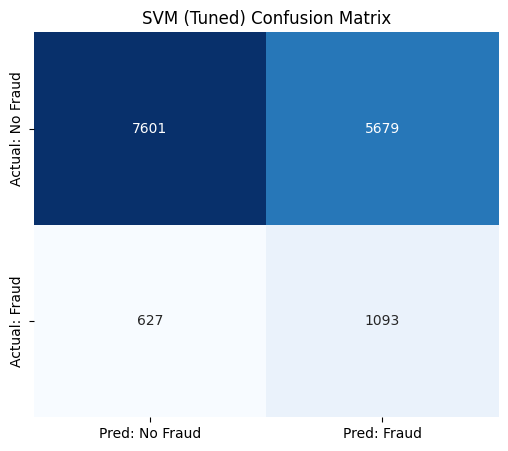

In [45]:
cm_svm = confusion_matrix(y_test, y_pred_best_svm)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_svm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["Pred: No Fraud", "Pred: Fraud"],
    yticklabels=["Actual: No Fraud", "Actual: Fraud"]
)
plt.title("SVM (Tuned) Confusion Matrix")
plt.xlabel("")
plt.ylabel("")
plt.show()

In [46]:
#Final comparison table
final_results = pd.DataFrame([
    log_metrics,
    tree_metrics,
    rf1_metrics,
    rf2_metrics,
    best_metrics,   # tuned RF
    svm_metrics     # tuned SVM
])

final_results.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1
2,Random Forest (Run 1),0.862000,0.350937,0.239535,0.284727
4,Random Forest (Tuned),0.820400,0.260806,0.308721,0.282748
1,Decision Tree,0.584133,0.164737,0.645349,0.262473
5,SVM (Tuned),0.579600,0.161400,0.635465,0.257419
0,Logistic Regression,0.597467,0.162867,0.606395,0.256770
3,Random Forest (Run 2),0.879800,0.400480,0.097093,0.156294
